# Task 3: CycleGAN Monet and Photo

This notebook trains a CycleGAN from scratch to turn Monet paintings into photos and photos into Monet paintings. The config name is read from the `CONFIG` environment variable (`local` or `gpu`).

## 1. Setup

In [1]:
import os
import random
import sys
from pathlib import Path

if Path.cwd().name == "src":
    os.chdir(Path.cwd().parent)
sys.path.append(str(Path.cwd() / "src"))
sys.path.append(str(Path.cwd()))

import copy
import itertools
import math
import shutil
import time

import lpips
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import yaml
from IPython.display import Image as show_image
from IPython.display import display
from PIL import Image

from data import ROOT, endless_pairs, get_data, load_config, load_samples, pick_eval_ids
from diffaug import diff_augment
import evaluate_local as ev
from evaluate_local import QuickScorer
from models import ImagePool, PatchDiscriminator, ResNetGenerator, build_discriminator, count_params
from utils import (Logger, get_device, load_checkpoint, make_scheduler, peak_memory_mb,
                   reset_peak_memory, save_checkpoint, save_ema_weights, save_sample_grid, set_seed,
                   write_predictions)

config_name = os.environ.get("CONFIG", "local")
cfg = load_config(config_name)
set_seed(cfg["seed"])
device, device_name = get_device()

out_dir = ROOT / cfg["paths"]["output_dir"]
out_dir.mkdir(parents=True, exist_ok=True)

print("working folder:", Path.cwd().name)
print("config:", config_name)
print("device:", device_name)

working folder: member_manav
config: gpu_ft_c25
device: NVIDIA GeForce RTX 4090


## 2. The Two Domains

In [2]:
sets, sample_ids = get_data(cfg)
monet_files = sets["monet_plain"].files
photo_files = sets["photo_plain"].files
print("Monet images (domain A):", len(monet_files))
print("Photo images (domain B):", len(photo_files))

sizes, modes = set(), set()
for file in monet_files + photo_files:
    with Image.open(file) as image:
        sizes.add(image.size)
        modes.add(image.mode)
print("image sizes:", sizes)
print("color modes:", modes)

Monet images (domain A): 300
Photo images (domain B): 7038


image sizes: {(256, 256)}
color modes: {'RGB'}


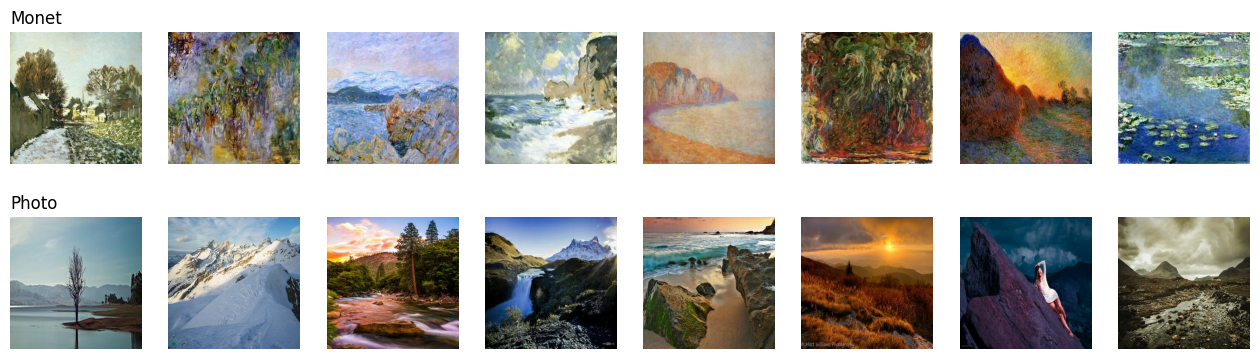

In [3]:
rng = random.Random(cfg["seed"])
shown = [("Monet", rng.sample(monet_files, min(8, len(monet_files)))),
         ("Photo", rng.sample(photo_files, min(8, len(photo_files))))]

fig, axes = plt.subplots(2, 8, figsize=(16, 4.4))
for row, (name, files) in enumerate(shown):
    for col, ax in enumerate(axes[row]):
        ax.axis("off")
        if col < len(files):
            ax.imshow(Image.open(files[col]))
    axes[row][0].set_title(name, loc="left")
plt.savefig(out_dir / "domains.png", dpi=150, bbox_inches="tight")
plt.show()

### The 300 vs 7038 imbalance

The full data has 300 Monet paintings but 7,038 photos, so there are about 23 photos for every painting. Because of this, I count training in steps, not epochs. Each step takes one random Monet and one random photo, so a single painting is used about 23 times more often than a single photo. The Monet side is small, so the model could start to memorize the paintings. This is why I use DiffAugment on the discriminator inputs.

## 3. Building the Models

In [4]:
m = cfg["model"]
G_A2B = ResNetGenerator(m["ngf"], m["n_res_blocks"], m.get("upsample", "transpose")).to(device)
G_B2A = ResNetGenerator(m["ngf"], m["n_res_blocks"], m.get("upsample", "transpose")).to(device)
D_A = build_discriminator(m["ndf"], m.get("spectral_norm", False), m.get("d_scales", 1)).to(device)
D_B = build_discriminator(m["ndf"], m.get("spectral_norm", False), m.get("d_scales", 1)).to(device)

nets = [("G_A2B", "turns Monet into photo", G_A2B),
        ("G_B2A", "turns photo into Monet", G_B2A),
        ("D_A", "judges Monet images", D_A),
        ("D_B", "judges photo images", D_B)]
table = pd.DataFrame({"network": [n[0] for n in nets],
                      "job": [n[1] for n in nets],
                      "parameters": [count_params(n[2]) for n in nets]})
table.loc[len(table)] = ["total", "", table["parameters"].sum()]
table

,network,job,parameters
0,G_A2B,turns Monet into photo,11378179
1,G_B2A,turns photo into Monet,11378179
2,D_A,judges Monet images,2764737
3,D_B,judges photo images,2764737
4,total,,28285832


## 4. Training

### Training setup

In [5]:
tcfg = cfg["train"]
total_steps = tcfg["total_steps"]
ckpt_dir = ROOT / cfg["paths"]["checkpoint_dir"]
sample_dir = out_dir / "samples"
sample_dir.mkdir(parents=True, exist_ok=True)

if device.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

ema_A2B = copy.deepcopy(G_A2B).eval().requires_grad_(False)
ema_B2A = copy.deepcopy(G_B2A).eval().requires_grad_(False)
models = {"G_A2B": G_A2B, "G_B2A": G_B2A, "D_A": D_A, "D_B": D_B,
          "ema_A2B": ema_A2B, "ema_B2A": ema_B2A}

betas = tuple(tcfg["betas"])
generator_params = list(itertools.chain(G_A2B.parameters(), G_B2A.parameters()))
optimizers = {
    "G": torch.optim.Adam(generator_params, lr=tcfg["lr"], betas=betas),
    "D_A": torch.optim.Adam(D_A.parameters(), lr=tcfg["lr"], betas=betas),
    "D_B": torch.optim.Adam(D_B.parameters(), lr=tcfg["lr"], betas=betas),
}
schedulers = {k: make_scheduler(v, tcfg["decay_start"], total_steps) for k, v in optimizers.items()}
pools = {"A": ImagePool(tcfg["pool_size"]), "B": ImagePool(tcfg["pool_size"])}

eval_ids = pick_eval_ids(len(photo_files), tcfg["eval_photos"], cfg["seed"])
eval_photos = load_samples(sets["photo_plain"], eval_ids)
all_monets = load_samples(sets["monet_plain"], list(range(len(monet_files))))
sample_photos = load_samples(sets["photo_plain"], sample_ids["photo"])
sample_monets = load_samples(sets["monet_plain"], sample_ids["monet"])
if tcfg.get("quick_metric", "legacy") == "official":
    scorer = ev.OfficialQuickScorer(device, sets["monet_plain"], sets["photo_plain"],
                                    ROOT / cfg["paths"]["data_dir"], out_dir / "quick_official_tmp")
else:
    scorer = QuickScorer(device, all_monets, eval_photos)

### Loss helpers

In [6]:
def augment(x):
    return diff_augment(x, tcfg["diffaug"])


def lsgan(pred, target):
    if isinstance(pred, list):
        return sum(F.mse_loss(p, torch.full_like(p, target)) for p in pred) / len(pred)
    return F.mse_loss(pred, torch.full_like(pred, target))


def grad_norm(params):
    return torch.nn.utils.clip_grad_norm_(params, float("inf")).item()


def set_requires_grad(nets, flag):
    for net in nets:
        net.requires_grad_(flag)


@torch.no_grad()
def update_ema(ema, model, decay):
    for e, p in zip(ema.parameters(), model.parameters()):
        e.mul_(decay).add_(p.detach(), alpha=1 - decay)


def train_discriminator(D, optimizer, real, fake, pool):
    loss = 0.5 * (lsgan(D(augment(real)), 1) + lsgan(D(augment(pool.query(fake))), 0))
    optimizer.zero_grad(set_to_none=True)
    if not torch.isfinite(loss):
        return None
    loss.backward()
    norm = grad_norm(list(D.parameters()))
    if not math.isfinite(norm):
        optimizer.zero_grad(set_to_none=True)
        return None
    optimizer.step()
    return loss.item(), norm

### Training loop

In [7]:
logger = Logger(out_dir / "train_log.txt")
logger.log(f"device: {device_name}")
logger.log(f"torch version: {torch.__version__}")
logger.log("config:\n" + yaml.dump(cfg, sort_keys=False))

history_path = out_dir / "history.csv"
scores_path = out_dir / "quick_scores.csv"
last_path = ckpt_dir / "last.pt"

step, history = 0, []
if last_path.exists():
    step, history = load_checkpoint(last_path, models, optimizers, schedulers, pools, device)
    for scheduler in schedulers.values():
        scheduler.base_lrs = [tcfg["lr"]] * len(scheduler.base_lrs)
    logger.log(f"resumed from step {step}")

reset_peak_memory(device)
pairs = endless_pairs(cfg, sets)
names = ["g_adv", "cycle", "identity", "d_a", "d_b", "grad_g", "grad_d_a", "grad_d_b"]
sums, count, nan_count = dict.fromkeys(names, 0.0), 0, 0
interval_start = time.time()

while step < total_steps:
    real_A, real_B = next(pairs)
    real_A, real_B = real_A.to(device), real_B.to(device)

    set_requires_grad([D_A, D_B], False)
    fake_B = G_A2B(real_A)
    fake_A = G_B2A(real_B)
    loss_adv = lsgan(D_B(augment(fake_B)), 1) + lsgan(D_A(augment(fake_A)), 1)
    loss_cycle = F.l1_loss(G_B2A(fake_B), real_A) + F.l1_loss(G_A2B(fake_A), real_B)
    loss_identity = F.l1_loss(G_B2A(real_A), real_A) + F.l1_loss(G_A2B(real_B), real_B)
    loss_G = loss_adv + tcfg["lambda_cycle"] * loss_cycle + tcfg["lambda_identity"] * loss_identity

    optimizers["G"].zero_grad(set_to_none=True)
    if not torch.isfinite(loss_G):
        nan_count += 1
        continue
    loss_G.backward()
    grad_g = grad_norm(generator_params)
    if not math.isfinite(grad_g):
        optimizers["G"].zero_grad(set_to_none=True)
        nan_count += 1
        continue
    optimizers["G"].step()

    set_requires_grad([D_A, D_B], True)
    result_a = train_discriminator(D_A, optimizers["D_A"], real_A, fake_A.detach(), pools["A"])
    result_b = train_discriminator(D_B, optimizers["D_B"], real_B, fake_B.detach(), pools["B"])
    if result_a is None or result_b is None:
        nan_count += 1
        continue

    update_ema(ema_A2B, G_A2B, tcfg["ema_decay"])
    update_ema(ema_B2A, G_B2A, tcfg["ema_decay"])
    for scheduler in schedulers.values():
        scheduler.step()
    step += 1

    for name, value in zip(names, [loss_adv.detach(), loss_cycle.detach(), loss_identity.detach(),
                                   result_a[0], result_b[0], grad_g, result_a[1], result_b[1]]):
        sums[name] += float(value)
    count += 1

    if step % tcfg["log_every"] == 0:
        elapsed = time.time() - interval_start
        row = {name: total / count for name, total in sums.items()}
        row.update(step=step, lr=optimizers["G"].param_groups[0]["lr"], nan_count=nan_count,
                   images_per_sec=2 * tcfg["batch_size"] * count / elapsed, seconds=elapsed)
        history.append(row)
        logger.log(f"step {step} | G adv {row['g_adv']:.3f} | cycle {row['cycle']:.3f} | "
                   f"identity {row['identity']:.3f} | D_A {row['d_a']:.3f} | D_B {row['d_b']:.3f} | "
                   f"grad G {row['grad_g']:.2f} D_A {row['grad_d_a']:.2f} D_B {row['grad_d_b']:.2f} | "
                   f"lr {row['lr']:.6f} | images/sec {row['images_per_sec']:.1f} | nan {nan_count}")
        sums, count = dict.fromkeys(names, 0.0), 0
        interval_start = time.time()

    if step % tcfg["ckpt_every"] == 0 or step == total_steps:
        pd.DataFrame(history).to_csv(history_path, index=False)
        save_checkpoint(last_path, step, models, optimizers, schedulers, pools, history)
        save_ema_weights(ckpt_dir / f"ema_step{step}.pt", {"G_A2B": ema_A2B, "G_B2A": ema_B2A})
        logger.log(f"saved checkpoint at step {step}")
        interval_start = time.time()

    if step % tcfg["eval_every"] == 0 or step == total_steps:
        scores = scorer.score(ema_A2B, ema_B2A, device)
        memory = peak_memory_mb(device)
        memory_text = f"{memory:.0f} MB" if memory is not None else "n/a"
        logger.log(f"quick score at step {step} | A2B FID {scores['fid_a2b']:.1f} MiFID {scores['mifid_a2b']:.3f} | "
                   f"B2A FID {scores['fid_b2a']:.1f} MiFID {scores['mifid_b2a']:.3f} | "
                   f"quick score {scores['quick_score']:.2f} | peak memory {memory_text}")
        pd.DataFrame([{"step": step, **scores, "peak_memory_mb": memory}]).to_csv(scores_path, mode="a", header=not scores_path.exists(), index=False)
        save_sample_grid(sample_dir / f"step{step}.png", sample_photos, sample_monets, ema_A2B, ema_B2A, device)
        interval_start = time.time()

    if nan_count > 1000:
        raise RuntimeError("too many NaN steps")

logger.log(f"training finished at step {step}")

device: NVIDIA GeForce RTX 4090
torch version: 2.14.1+cu132
config:
seed: 42
run_name: gpu_ft_c25
paths:
  data_dir: ../data
  checkpoint_dir: checkpoints/gpu_ft_c25
  output_dir: outputs/gpu_ft_c25
data:
  image_size: 256
  load_size: 286
  monet_limit: null
  photo_limit: null
  num_workers: 4
train:
  total_steps: 160000
  decay_start: 140000
  batch_size: 1
  lr: 0.0001
  betas:
  - 0.5
  - 0.999
  ema_decay: 0.999
  pool_size: 50
  lambda_cycle: 2.5
  lambda_identity: 0
  diffaug: color,translation,cutout
  ckpt_every: 5000
  eval_every: 5000
  eval_photos: 1000
  log_every: 200
  quick_metric: official
model:
  n_res_blocks: 9
  ngf: 64
  ndf: 64
output:
  jpg_quality: 95



resumed from step 140000


step 140200 | G adv 0.718 | cycle 0.154 | identity 0.270 | D_A 0.226 | D_B 0.242 | grad G 14.88 D_A 12.42 D_B 7.01 | lr 0.000099 | images/sec 5.5 | nan 0


step 140400 | G adv 0.724 | cycle 0.169 | identity 0.362 | D_A 0.228 | D_B 0.238 | grad G 14.84 D_A 11.62 D_B 6.77 | lr 0.000098 | images/sec 11.5 | nan 0


step 140600 | G adv 0.661 | cycle 0.181 | identity 0.307 | D_A 0.229 | D_B 0.244 | grad G 13.00 D_A 11.27 D_B 5.99 | lr 0.000097 | images/sec 11.8 | nan 0


...

step 159800 | G adv 0.616 | cycle 0.141 | identity 0.337 | D_A 0.229 | D_B 0.237 | grad G 12.82 D_A 11.08 D_B 3.90 | lr 0.000001 | images/sec 23.3 | nan 0


step 160000 | G adv 0.599 | cycle 0.140 | identity 0.328 | D_A 0.225 | D_B 0.238 | grad G 12.19 D_A 10.32 D_B 3.81 | lr 0.000000 | images/sec 22.4 | nan 0


saved checkpoint at step 160000


quick score at step 160000 | A2B FID 103.4 MiFID 0.425 | B2A FID 100.0 MiFID 0.409 | quick score 51.05 | peak memory 10959 MB


training finished at step 160000


## 5. Training Curves

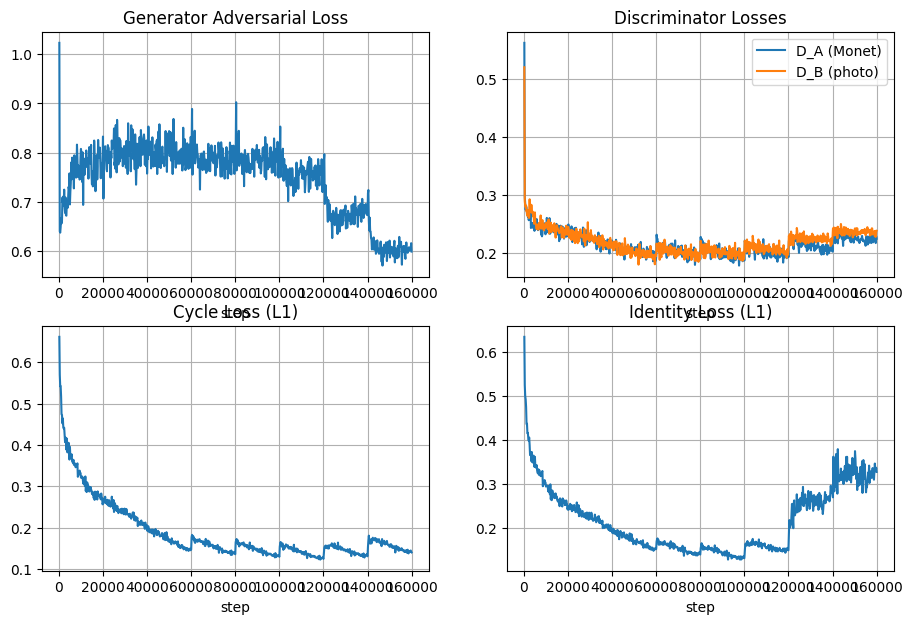

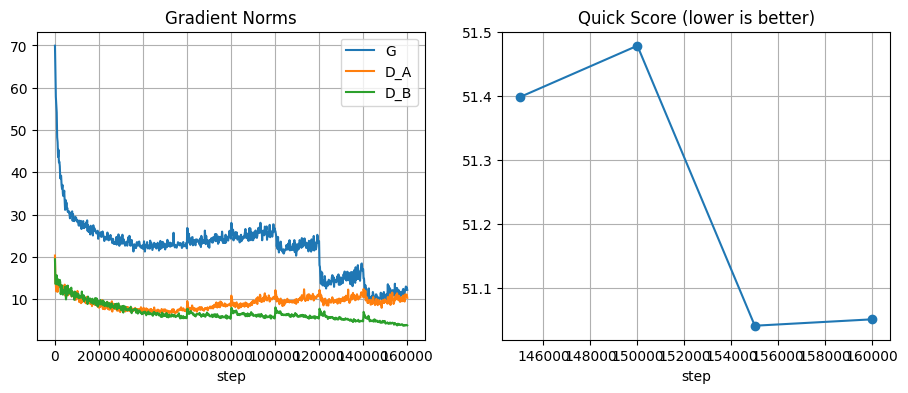

In [8]:
history_df = pd.read_csv(history_path)
scores_df = pd.read_csv(scores_path).drop_duplicates("step", keep="last")

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes[0][0].plot(history_df["step"], history_df["g_adv"])
axes[0][0].set_title("Generator Adversarial Loss")
axes[0][1].plot(history_df["step"], history_df["d_a"], label="D_A (Monet)")
axes[0][1].plot(history_df["step"], history_df["d_b"], label="D_B (photo)")
axes[0][1].set_title("Discriminator Losses")
axes[0][1].legend()
axes[1][0].plot(history_df["step"], history_df["cycle"])
axes[1][0].set_title("Cycle Loss (L1)")
axes[1][1].plot(history_df["step"], history_df["identity"])
axes[1][1].set_title("Identity Loss (L1)")
for ax in axes.flatten():
    ax.set_xlabel("step")
    ax.grid(True)
plt.savefig(out_dir / "loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_df["step"], history_df["grad_g"], label="G")
axes[0].plot(history_df["step"], history_df["grad_d_a"], label="D_A")
axes[0].plot(history_df["step"], history_df["grad_d_b"], label="D_B")
axes[0].set_title("Gradient Norms")
axes[0].legend()
axes[1].plot(scores_df["step"], scores_df["quick_score"], marker="o")
axes[1].set_title("Quick Score (lower is better)")
for ax in axes:
    ax.set_xlabel("step")
    ax.grid(True)
plt.savefig(out_dir / "grad_norms_and_score.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Picking the Best Checkpoint

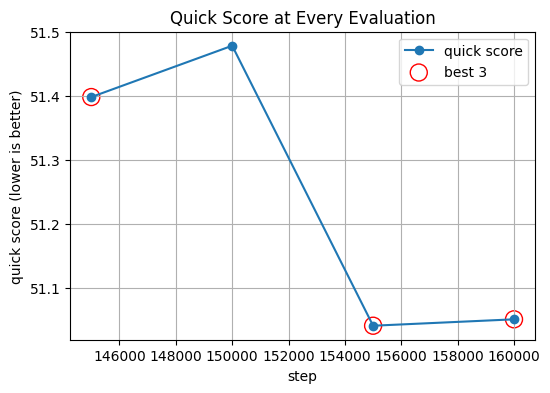

In [9]:
scores_df = pd.read_csv(scores_path).drop_duplicates("step", keep="last").sort_values("step")
has_ema = scores_df["step"].map(lambda s: (ckpt_dir / f"ema_step{s}.pt").exists())
candidates = scores_df[has_ema].nsmallest(3, "quick_score")

plt.figure(figsize=(6, 4))
plt.plot(scores_df["step"], scores_df["quick_score"], marker="o", label="quick score")
plt.scatter(candidates["step"], candidates["quick_score"], s=150, facecolors="none", edgecolors="red", label="best 3")
plt.xlabel("step")
plt.ylabel("quick score (lower is better)")
plt.title("Quick Score at Every Evaluation")
plt.legend()
plt.grid(True)
plt.savefig(out_dir / "quick_scores.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
eval_log = Logger(out_dir / "eval_log.txt")
jpg_quality = cfg.get("output", {}).get("jpg_quality", 95)
choice_rows = []
for _, row in candidates.iterrows():
    candidate_step = int(row["step"])
    candidate_ckpt = ckpt_dir / f"ema_step{candidate_step}.pt"
    work_dir = out_dir / "candidates" / f"step{candidate_step}"
    cand_a2b, cand_b2a = ev.load_generators(cfg, candidate_ckpt, device)
    write_predictions(sets["monet_plain"], cand_a2b, work_dir / "pred_A2B", device, quality=jpg_quality)
    write_predictions(sets["photo_plain"], cand_b2a, work_dir / "pred_B2A", device, quality=jpg_quality)
    candidate_submission, _ = ev.evaluate(config_name, candidate_ckpt, work_dir, verbose=False)
    by_direction = candidate_submission.set_index(ev.SUBMISSION_COLUMNS["direction"])[ev.SUBMISSION_COLUMNS["score"]]
    choice_rows.append({"step": candidate_step, "quick_score": row["quick_score"],
                        "A2B_score": by_direction["A2B"], "B2A_score": by_direction["B2A"],
                        "overall_score": by_direction["overall"]})
    shutil.rmtree(work_dir / "pred_A2B")
    shutil.rmtree(work_dir / "pred_B2A")

choice = pd.DataFrame(choice_rows)
best_step = int(choice.loc[choice["overall_score"].idxmin(), "step"])
choice["chosen"] = choice["step"] == best_step
choice.to_csv(out_dir / "checkpoint_choice.csv", index=False)
for r in choice.itertuples():
    eval_log.log(f"checkpoint step {r.step}: quick score {r.quick_score:.2f} | overall score {r.overall_score:.2f}"
                 + (" <- chosen" if r.chosen else ""))
eval_log.log(f"chosen checkpoint: ema_step{best_step}.pt")
choice

C:\Users\manav\Documents\Lab - 1\data266-lab1-pair17\.venv\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\manav\Documents\Lab - 1\data266-lab1-pair17\.venv\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


C:\Users\manav\Documents\Lab - 1\data266-lab1-pair17\.venv\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\manav\Documents\Lab - 1\data266-lab1-pair17\.venv\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


C:\Users\manav\Documents\Lab - 1\data266-lab1-pair17\.venv\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\manav\Documents\Lab - 1\data266-lab1-pair17\.venv\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


checkpoint step 155000: quick score 51.04 | overall score 40.82 <- chosen
checkpoint step 160000: quick score 51.05 | overall score 41.17
checkpoint step 145000: quick score 51.40 | overall score 41.66
chosen checkpoint: ema_step155000.pt


,step,quick_score,A2B_score,B2A_score,overall_score,chosen
0,155000,51.041530,41.840930,39.791174,40.816052,True
1,160000,51.051517,41.532577,40.810825,41.171701,False
2,145000,51.398350,41.958921,41.356441,41.657681,False


## 7. Translating All Images

In [11]:
chosen_ckpt = ckpt_dir / f"ema_step{best_step}.pt"
g_a2b, g_b2a = ev.load_generators(cfg, chosen_ckpt, device)
for name in ["pred_A2B", "pred_B2A"]:
    if (out_dir / name).exists():
        shutil.rmtree(out_dir / name)

start = time.time()
n_monet = write_predictions(sets["monet_plain"], g_a2b, out_dir / "pred_A2B", device, quality=jpg_quality)
n_photo = write_predictions(sets["photo_plain"], g_b2a, out_dir / "pred_B2A", device, quality=jpg_quality)
translate_speed = (n_monet + n_photo) / (time.time() - start)

eval_log.log(f"translated {n_monet} Monets to pred_A2B and {n_photo} photos to pred_B2A")
eval_log.log(f"translation speed: {translate_speed:.1f} images/sec")

translated 300 Monets to pred_A2B and 7038 photos to pred_B2A
translation speed: 66.4 images/sec


## 8. Results

In [12]:
submission, report = ev.evaluate(config_name, chosen_ckpt)
print("submission.csv")
display(submission)
print("full_metrics_report.csv")
display(report)

checks passed: 300 A2B and 7038 B2A images, all 256x256 RGB JPG


C:\Users\manav\Documents\Lab - 1\data266-lab1-pair17\.venv\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\manav\Documents\Lab - 1\data266-lab1-pair17\.venv\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


pretrained weights used only for measuring images:
  Inception-v3 (FID): C:\Users\manav\.cache\torch\hub\checkpoints\weights-inception-2015-12-05-6726825d.pth (91.2 MB)
  AlexNet (LPIPS backbone): C:\Users\manav\.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth (233.1 MB)
  LPIPS linear layers: C:\Users\manav\Documents\Lab - 1\data266-lab1-pair17\.venv\Lib\site-packages\lpips\weights\v0.1\alex.pth (0.0 MB)


submission.csv


,direction,FID,MiFID,score
0,A2B,83.264017,0.417842,41.840930
1,B2A,79.179034,0.403315,39.791174
2,overall,81.221525,0.410579,40.816052


full_metrics_report.csv


,direction,FID,MiFID,score,KID_mean,KID_std,precision,recall,LPIPS,content_cosine,cycle_L1,n_fake,n_real
0,A2B,83.264017,0.417842,41.840930,0.020441,0.000897,0.610000,0.393333,0.340297,0.790658,0.078577,300.0,7038.0
1,B2A,79.179034,0.403315,39.791174,0.009691,0.000776,0.506667,0.573333,0.402390,0.740106,0.095333,7038.0,300.0
2,overall,81.221525,0.410579,40.816052,0.015066,0.000836,0.558333,0.483333,0.371343,0.765382,0.086955,NaN,NaN


In [13]:
history_df = pd.read_csv(history_path)
total_params = sum(count_params(net) for net in [G_A2B, G_B2A, D_A, D_B])
generator_params = count_params(G_A2B) + count_params(G_B2A)
peak_memory = scores_df["peak_memory_mb"].max()

summary = pd.DataFrame({"value": {
    "chosen checkpoint": f"ema_step{best_step}.pt",
    "parameters (all four networks)": f"{total_params:,}",
    "parameters (two generators)": f"{generator_params:,}",
    "training steps": int(history_df["step"].max()),
    "training time": f"{history_df['seconds'].sum() / 60:.1f} min",
    "training speed": f"{history_df['images_per_sec'].mean():.1f} images/sec",
    "translation speed": f"{translate_speed:.1f} images/sec",
    "peak memory": f"{peak_memory:.0f} MB" if pd.notna(peak_memory) else "n/a",
    "device": device_name,
}})
summary

,value
chosen checkpoint,ema_step155000.pt
parameters (all four networks),"28,285,832"
parameters (two generators),"22,756,358"
training steps,160000
training time,333.5 min
training speed,18.7 images/sec
translation speed,66.4 images/sec
peak memory,10959 MB
device,NVIDIA GeForce RTX 4090


## 9. Cycle Consistency Check

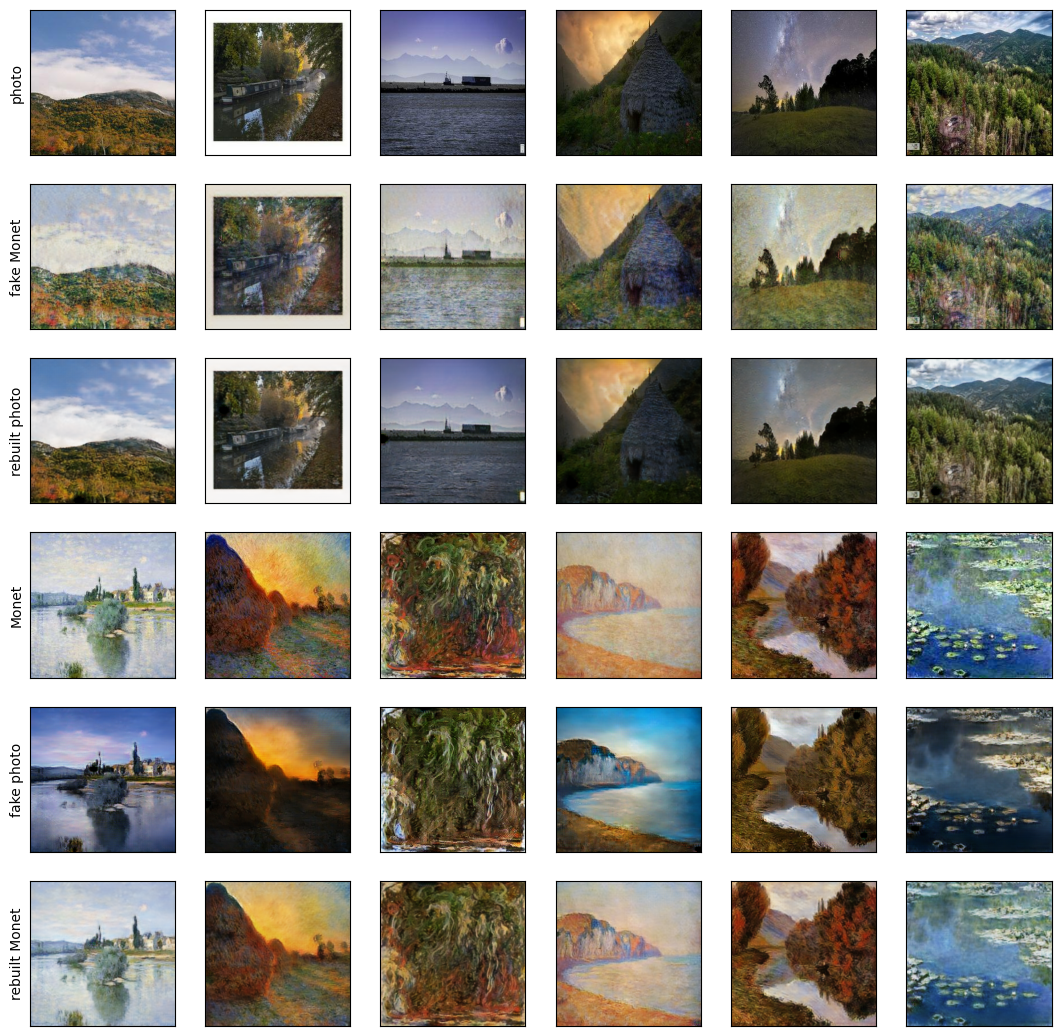

cycle L1, Monet -> photo -> Monet: 0.0786
cycle L1, photo -> Monet -> photo: 0.0953


In [14]:
pick = random.Random(cfg["seed"])
cycle_photos = load_samples(sets["photo_plain"], sorted(pick.sample(range(len(photo_files)), min(6, len(photo_files)))))
cycle_monets = load_samples(sets["monet_plain"], sorted(pick.sample(range(len(monet_files)), min(6, len(monet_files)))))
save_sample_grid(out_dir / "cycle_check.png", cycle_photos, cycle_monets, g_a2b, g_b2a, device)
display(show_image(filename=str(out_dir / "cycle_check.png")))

cycle_l1 = report.set_index("direction")["cycle_L1"]
print(f"cycle L1, Monet -> photo -> Monet: {cycle_l1['A2B']:.4f}")
print(f"cycle L1, photo -> Monet -> photo: {cycle_l1['B2A']:.4f}")

## 10. Failure Cases

C:\Users\manav\Documents\Lab - 1\data266-lab1-pair17\.venv\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\manav\Documents\Lab - 1\data266-lab1-pair17\.venv\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


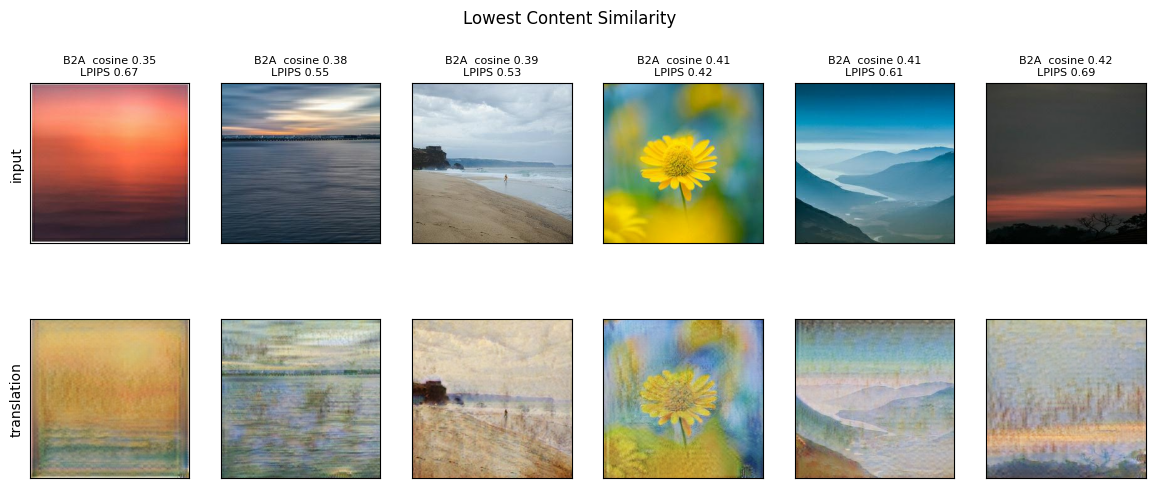

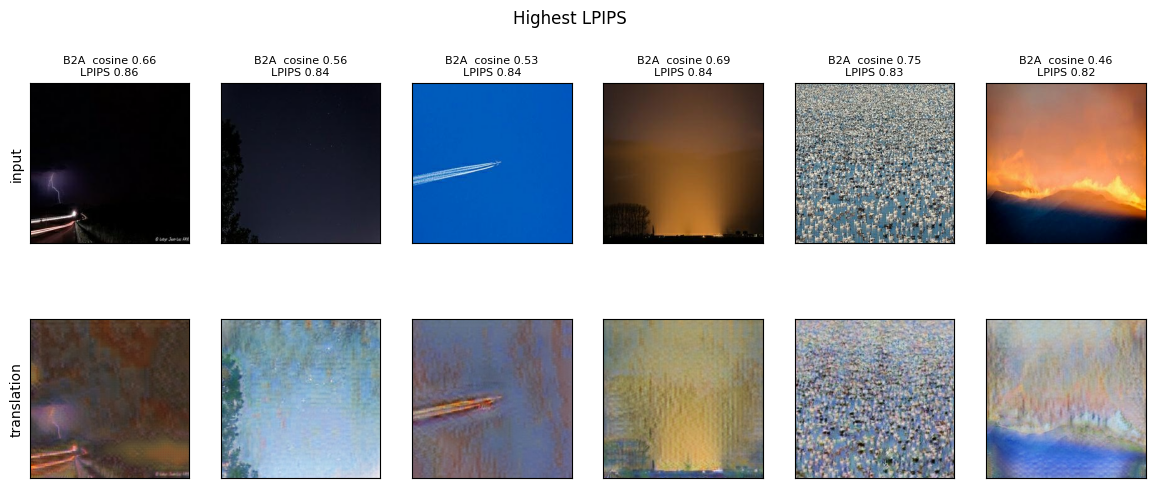

In [15]:
eval_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
inception = ev.load_inception(eval_device)
lpips_net = lpips.LPIPS(net="alex", verbose=False).to(eval_device).eval()
data_dir = (ROOT / cfg["paths"]["data_dir"]).resolve()
image_size = cfg["data"]["image_size"]

tables = []
for direction, input_files in [("A2B", monet_files), ("B2A", photo_files)]:
    pred_files = [out_dir / f"pred_{direction}" / f.name for f in input_files]
    input_features = ev.file_features(inception, input_files, image_size, eval_device)
    pred_features = ev.file_features(inception, pred_files, image_size, eval_device)
    tables.append(pd.DataFrame({
        "direction": direction,
        "file": [f.name for f in input_files],
        "content_cosine": ev.cosine_per_row(input_features, pred_features),
        "lpips": ev.lpips_per_image(lpips_net, input_files, pred_files, image_size, eval_device),
    }))
all_scores = pd.concat(tables, ignore_index=True)
all_scores.to_csv(out_dir / "per_image_scores.csv", index=False)


def show_pairs(table, title, path):
    fig, axes = plt.subplots(2, len(table), figsize=(2.4 * len(table), 5.6), squeeze=False)
    for col, (_, r) in enumerate(table.iterrows()):
        input_folder = "monet_jpg" if r["direction"] == "A2B" else "photo_jpg"
        axes[0][col].imshow(Image.open(data_dir / input_folder / r["file"]))
        axes[1][col].imshow(Image.open(out_dir / f"pred_{r['direction']}" / r["file"]))
        axes[0][col].set_title(f"{r['direction']}  cosine {r['content_cosine']:.2f}\nLPIPS {r['lpips']:.2f}", fontsize=8)
    for ax in axes.flatten():
        ax.set_xticks([])
        ax.set_yticks([])
    axes[0][0].set_ylabel("input")
    axes[1][0].set_ylabel("translation")
    fig.suptitle(title)
    fig.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()


show_pairs(all_scores.nsmallest(6, "content_cosine"), "Lowest Content Similarity", out_dir / "failures_low_content.png")
show_pairs(all_scores.nlargest(6, "lpips"), "Highest LPIPS", out_dir / "failures_high_lpips.png")